# ClaimStruct

## Clasificación y Estructuración Automática de Reclamos Bancarios
Proyecto Final – Materia Deep Learning

Especialización en Ciencia de Datos e Inteligencia Artificial

Autores:
Leticia Colombo y Jeasmine Ñahui



## Introducción

Este notebook corresponde al proyecto final de la materia Deep Learning, en el marco de la Especialización en Ciencia de Datos e Inteligencia Artificial.

El objetivo del proyecto es desarrollar un sistema basado en modelos de lenguaje tipo Transformer capaz de clasificar automáticamente reclamos bancarios redactados en texto libre y extraer información relevante en formato estructurado. La propuesta aborda una problemática real vinculada a la clasificación manual de conversaciones que ingresan por canales digitales como chat, aplicación móvil y web, proceso que actualmente requiere intervención humana y presenta desafíos en términos de eficiencia operativa, consistencia y trazabilidad.

La solución propuesta no funciona como chatbot ni genera respuestas automáticas al cliente. Su propósito es actuar como un motor interno de clasificación y estructuración que permita identificar la intención principal del reclamo, detectar entidades relevantes como producto y motivo, y generar registros estructurados que faciliten el análisis posterior y el enrutamiento hacia equipos humanos.

Debido a restricciones de confidencialidad y acceso a información sensible, el dataset utilizado es sintético y fue generado con apoyo de modelos de lenguaje. Se diseñó cuidadosamente para asegurar diversidad lingüística, representación de los principales tipos de reclamo y balance entre clases, permitiendo así realizar entrenamiento y evaluación de modelos de manera rigurosa.

Este archivo corresponde al entrenamiento del modelo, continuación del EDA.

Aclaración: Durante la ejecución se le va a pedir ingresar el claimstruct_multitable_v2.zip, ingresarlo utilizando la utilidad de cargar archivo.

Debido a distintas pruebas, se concluye no utilizar el dataset con aumentation ni unicidad, en cambio se construye un dataset de conversaciones completo, generando un split aleatorio interno (train/val/test) estratificado por intención, de esta forma evitar overfitting para este escenario.

## Importacion de librerías

De existir un error al instalar las dependencias des-comentar las siguientes lineas

In [ ]:
# !pip uninstall -y transformers
# !pip install transformers==4.41.2

In [ ]:
from __future__ import annotations

import json
import os
import random
import re
import textwrap
import warnings
import zipfile
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from scipy import stats
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, TFAutoModel, TFBertModel

In [ ]:
# Fuerza a que las operaciones internas de TensorFlow produzcan resultados reproducibles
tf.config.experimental.enable_op_determinism()

In [ ]:
warnings.filterwarnings("ignore")
# Controla el nivel de logs de TensorFlow. 2 oculta INFO y WARNING
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

## Configuración

In [ ]:
@dataclass
class Config:
    # --- Configuracion de visualizacion ---
    palette: list = field(default_factory=lambda: [
        '#a5c4beff',  # verde salvia suave
        '#ffc0c0ff',  # rosa pastel
        '#3f5a6bff',  # azul petróleo
        '#f38681ff',  # coral suave
        '#00c3b1ff',  # turquesa vibrante
        '#6c8ea3ff',  # azul grisáceo medio
        '#b8a1c9ff',  # lavanda apagada
        '#f2b880ff',  # durazno cálido
        '#7bbfa5ff',  # verde menta medio
        '#d97d54ff',  # terracota suave
    ])
    bg_color: str = "#f7ecdcff" # Color de fondo de las figuras
    fig_w: int = 10             # Ancho de las figuras en pulgadas
    fig_h: int = 4              # Alto de las figuras en pulgadas
    dpi: int = 130              # Resolucion de las figuras
    sample_pairplot: int = 2000 # Cantidad de muestras para el pairplot (evita graficos lentos)
    seed: int = 42              # Semilla para reproducibilidad

    # --- Configuracion del modelo BERT ---
    bert_model_name: str = "dccuchile/bert-base-spanish-wwm-cased"  # Modelo preentrenado en español
    # 256 tokens para acomodar conversaciones completas (mas largas que un solo mensaje)
    max_length: int = 256

    # --- Configuracion del entrenamiento ---
    batch_size: int = 16              # Cantidad de muestras por batch
    epochs: int = 10                  # Numero maximo de epocas de entrenamiento
    learning_rate: float = 3e-5       # Tasa de aprendizaje (valor tipico para fine-tuning de BERT)
    early_stopping_patience: int = 3  # Epocas sin mejora antes de detener el entrenamiento
    intent_loss_weight: float = 1.0   # Peso de la loss de clasificacion de intents
    ner_loss_weight: float = 1.0      # Peso de la loss de NER (balance entre ambas tareas)
    dropout_rate: float = 0.3         # Tasa de dropout para regularizacion del modelo (0.0 = sin dropout, 1.0 = todo apagado)

    # --- Configuracion general ---
    seed: int = 42                # Semilla para reproducibilidad
    ner_ignore_index: int = -100  # Valor que indica tokens a ignorar en el calculo de la loss NER

    # --- Configuracion del preprocesamiento de texto ---
    # Separador entre mensajes dentro de una conversacion
    msg_separator: str = " [SEP] "
    # Prefijos para identificar al hablante en el texto concatenado (ej: "[AGENT] ", "[CLIENT] ")
    speaker_prefix: bool = True

# Instanciar configuracion global
cfg = Config()

In [ ]:
sns.set_theme(
    style="white",
    rc={
        "figure.facecolor": cfg.bg_color,
        "axes.facecolor": cfg.bg_color
    }
)

In [ ]:
def set_global_seed(seed):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Fuerza operaciones deterministas en GPU (muy importante)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [ ]:
set_global_seed(cfg.seed)

## Metodos utilitarios

### Helpers de datos

In [ ]:
def extract_zip(zip_path: str, extract_dir: str) -> None:
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)


def safe_read_csv(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

In [ ]:
def mostrar_conversaciones_random(df, n_conversations=3):
    conv_ids = df["conversation_id"].dropna().unique()

    selected_convs = random.sample(
        list(conv_ids),
        min(n_conversations, len(conv_ids))
    )

    for cid in selected_convs:
        df_conv = df[df["conversation_id"] == cid] \
            .sort_values("timestamp_offset_sec")

        # Tomar reason_code_primary (puede repetirse dentro de la conv)
        reason = df_conv["reason_code_primary"].dropna().iloc[0] \
            if "reason_code_primary" in df_conv.columns else "UNKNOWN"

        print("\n" + "="*80)
        print(f"CONVERSATION ID: {cid}")
        print(f"REASON CODE: {reason}")
        print("="*80)

        for _, row in df_conv.iterrows():

            print(f"[{row['speaker'].upper()}] {row['text']}")
            print()

        print("="*80 + "\n")

In [ ]:
def check_col(df: pd.DataFrame, col: str) -> bool:
    """Verifica que la columna exista y tenga datos no nulos."""
    return col in df.columns and df[col].notna().any()

In [ ]:
def crosstab_safe(df: pd.DataFrame,
                  row: str,
                  col: str) -> Optional[pd.DataFrame]:
    """Crosstab solo si ambas columnas tienen datos."""
    if check_col(df, row) and check_col(df, col):
        return pd.crosstab(df[row], df[col])
    return None

In [ ]:
def agregar_por_conversacion(messages: pd.DataFrame, entities: pd.DataFrame) -> pd.DataFrame:
    """Calcula metricas agregadas por conversacion: mensajes, palabras, duracion, entidades."""
    # Agrupa los mensajes por conversacion y calcula metricas de texto y duracion
    msg_agg = messages.groupby("conversation_id").agg(
        # Cantidad total de mensajes en la conversacion
        n_msgs=("message_id", "size"),
        # Total de palabras sumando las palabras de cada mensaje
        total_words=("text", lambda x: x.astype(str).str.split().str.len().sum()),
        # Total de caracteres sumando la longitud de cada mensaje
        total_chars=("text", lambda x: x.astype(str).str.len().sum()),
        # Duracion en segundos
        duracion_sec=("timestamp_offset_sec", lambda x: x.max() - x.min()),
    ).reset_index()

    # Agrupa las entidades por conversacion y calcula metricas de entidades
    ent_agg = entities.groupby("conversation_id").agg(
        # Cantidad total de entidades detectadas en la conversacion
        n_entities=("entity_type", "size"),
        # Cantidad de tipos de entidades distintos (ej: PERSON, ORG, DATE...)
        n_entity_types=("entity_type", "nunique"),
    ).reset_index()

    # Une ambas tablas por conversation_id usando left join para conservar
    # todas las conversaciones, incluso las que no tienen entidades
    df = msg_agg.merge(ent_agg, on="conversation_id", how="left")

    # Las conversaciones sin entidades quedan con NaN tras el merge,
    # se reemplazan por 0
    df[["n_entities", "n_entity_types"]] = df[["n_entities", "n_entity_types"]].fillna(0).astype(int)

    return df

In [ ]:
def encode_categoricals(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """Codifica columnas categoricas como enteros para calcular correlaciones."""
    out = df[cols].copy()
    for c in cols:
        out[c] = out[c].astype("category").cat.codes
    return out

In [ ]:
def print_dataframe_info(name: str, df: pd.DataFrame) -> None:
    """
    Imprime información estructural básica de un DataFrame.
    """
    print("\n" + "=" * 60)
    print(f"{name.upper()}")
    print("=" * 60)

    print("\nShape:")
    print(df.shape)

    print("\nColumnas:")
    print(list(df.columns))

    print("\nTipos de datos:")
    print(df.dtypes)

    print("\nValores nulos por columna:")
    print(df.isnull().sum().sort_values(ascending=False))

    print("\nMemoria aproximada en MB:")
    print(round(df.memory_usage(deep=True).sum() / 1024**2, 3))

    print("\nEstadísticas descriptivas:")
    print(df.describe(include="all"))

In [ ]:
def print_multiple_dataframes_info(dfs: dict) -> None:
    """
    Recibe un diccionario {nombre: dataframe} y muestra info para cada uno.
    """
    print("===== INFORMACIÓN GENERAL =====")
    for name, df in dfs.items():
        print_dataframe_info(name, df)

## Montado de dataset

El siguiente codigo comentado es para uso interno de Leticia y Jeasmine

In [ ]:
# try:
#     from google.colab import drive
#     drive.mount('/content/drive')
#     print("Drive montado correctamente.")

#     path = '/content/drive/MyDrive/CIENCIA_DE_DATOS_UTEC/Trabajo_final/Deep Learning/'
#     zip_path = path + "claimstruct_multitable_v2.zip"
#     extract_dir = "/content/claimstruct_multitable_v2"

#     extract_zip(zip_path, extract_dir)
# except:
#     print("No se ejecuta en Colab o Drive ya está montado.")

In [ ]:
"""## Carga del dataset

El dataset se puede cargar de tres formas:
1. **Upload interactivo en Colab**: se muestra un diálogo para subir el ZIP.
2. **Path local**: si el ZIP ya está en el directorio de trabajo (ejecuciones previas o entorno local).
3. **Google Drive**: si se monta Drive manualmente, ajustar `ZIP_FILENAME` al path correspondiente.
"""

ZIP_FILENAME = "claimstruct_multitable_v2.zip"
extract_dir = "/content/claimstruct_multitable_v2"

if not os.path.exists(ZIP_FILENAME):
    try:
        from google.colab import files
        print(f"No se encontró '{ZIP_FILENAME}' en el directorio actual.")
        print("Por favor, suba el archivo ZIP del dataset.")
        uploaded = files.upload()
        # Si el usuario subió un archivo con nombre diferente, renombrar
        uploaded_name = list(uploaded.keys())[0]
        if uploaded_name != ZIP_FILENAME:
            os.rename(uploaded_name, ZIP_FILENAME)
            print(f"Archivo renombrado: '{uploaded_name}' → '{ZIP_FILENAME}'")
    except ImportError:
        raise FileNotFoundError(
            f"No se encontró '{ZIP_FILENAME}' en el directorio de trabajo. "
            "Coloque el archivo ZIP en el directorio actual o ejecute en Google Colab."
        )

extract_zip(ZIP_FILENAME, extract_dir)
print(f"Dataset extraído en: {extract_dir}")

In [ ]:
conversations_path = os.path.join(extract_dir, "conversations.csv")
messages_path = os.path.join(extract_dir, "messages.csv")
labels_path = os.path.join(extract_dir, "labels.csv")
entities_path = os.path.join(extract_dir, "entities.csv")

conversations = safe_read_csv(conversations_path)
messages = safe_read_csv(messages_path)
labels = safe_read_csv(labels_path)
entities = safe_read_csv(entities_path)

In [ ]:
print("Shapes:")
for n, df in [("messages", messages), ("labels", labels),
              ("entities", entities), ("conversations", conversations)]:
    print(f"  {n}: {df.shape}")

Shapes:
  messages: (46713, 5)
  labels: (8000, 13)
  entities: (16502, 9)
  conversations: (8000, 10)


## Análisis de Datos

### Sanity Check e Integridad

El dataset generado está estructurado en cuatro tablas bien diferenciasdas:
- conversations (8000 filas)
- messages (46.713 filas)
- labels (8000 filas)
- entirites(16.502 filas)


La unidad principal de análisis es la conversaciòn, mientras que el texto está fragmentado en múltimples mensajes por conversación.


Desde el punto de  vista de  calidad de los datos, es un dataset limpio ya que no hay valores nulos en conversations, messages ni entities, si hay en labels pero esto es porque es opcional.

In [ ]:
print_multiple_dataframes_info({
    "Conversations": conversations,
    "Messages": messages,
    "Labels": labels,
    "Entities": entities
})

===== INFORMACIÓN GENERAL =====

CONVERSATIONS

Shape:
(8000, 10)

Columnas:
['conversation_id', 'created_at', 'channel', 'language', 'customer_segment', 'country', 'product_hint', 'is_synthetic', 'dataset_version', 'split']

Tipos de datos:
conversation_id     object
created_at          object
channel             object
language            object
customer_segment    object
country             object
product_hint        object
is_synthetic          bool
dataset_version     object
split               object
dtype: object

Valores nulos por columna:
conversation_id     0
created_at          0
channel             0
language            0
customer_segment    0
country             0
product_hint        0
is_synthetic        0
dataset_version     0
split               0
dtype: int64

Memoria aproximada en MB:
4.07

Estadísticas descriptivas:
       conversation_id           created_at channel language customer_segment  \
count             8000                 8000    8000     8000            

### Exploración del dataset

In [ ]:
labels.head()

,conversation_id,intent_primary,intent_secondary,product_final,reason_code_primary,severity,fraud_risk,outcome,routing_queue,label_source,labeler_id,label_version,split
0,conv_001706,rechazo_prevencion_fraude,fraude_desconocimiento,tarjeta_debito,autorizacion_rechazada_prevencion_fraude,medium,medium,escalated,cards_ops,synthetic,generator,v1,train
1,conv_006186,acreditacion_transferencia,acreditacion_pago,transferencia,no_acredita_transferencia,low,low,resolved,accounts_ops,synthetic,generator,v1,train
2,conv_000900,rechazo_prevencion_fraude,NaN,tarjeta_debito,autorizacion_rechazada_prevencion_fraude,medium,medium,resolved,cards_ops,synthetic,generator,v1,train
3,conv_007454,acceso_canales_digitales,NaN,canales_digitales,problema_acceso_clave,low,low,resolved,digital_support,synthetic,generator,v1,train
4,conv_002773,controversia_compra,NaN,tarjeta_credito,controversia_compra,medium,low,escalated,cards_ops,synthetic,generator,v1,train


In [ ]:
entities.head()

,conversation_id,message_id,entity_type,start_char,end_char,text_span,normalized_value,confidence,extractor_source
0,conv_000001,conv_000001_msg_002,amount,38,43,89.00,89.00,0.95,synthetic
1,conv_000001,conv_000001_msg_002,currency,44,47,EUR,EUR,0.91,synthetic
2,conv_000001,conv_000001_msg_004,country,22,36,Estados Unidos,ESTADOS UNIDOS,0.94,synthetic
3,conv_000002,conv_000002_msg_004,country,22,36,Estados Unidos,ESTADOS UNIDOS,0.88,synthetic
4,conv_000003,conv_000003_msg_002,amount,38,43,"59,99","59,99",0.96,synthetic


In [ ]:
conversations.head()

,conversation_id,created_at,channel,language,customer_segment,country,product_hint,is_synthetic,dataset_version,split
0,conv_000001,2025-03-18T11:24:00,callcenter,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,train
1,conv_000002,2025-05-01T03:49:00,app,es,retail,Uruguay,tarjeta_credito,True,v2_realistic_multitable,train
2,conv_000003,2025-04-24T17:16:00,callcenter,es,retail,Uruguay,tarjeta_credito,True,v2_realistic_multitable,train
3,conv_000004,2025-02-17T08:07:00,chat,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,train
4,conv_000005,2025-02-15T20:14:00,callcenter,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,test


In [ ]:
messages.head()

,conversation_id,message_id,speaker,timestamp_offset_sec,text
0,conv_000001,conv_000001_msg_001,customer,0,"Hola, buenas. Soy Valentina. Estoy intentando ..."
1,conv_000001,conv_000001_msg_002,customer,31,Me figura autorización rechazada por 89.00 EUR.
2,conv_000001,conv_000001_msg_003,agent,57,"Bien, reviso seguridad. ¿La compra es por inte..."
3,conv_000001,conv_000001_msg_004,customer,79,Es por internet desde Estados Unidos. En el su...
4,conv_000001,conv_000001_msg_005,agent,108,Soporte: Puede ser prevención de fraude. Podem...


In [ ]:
messages_labels = pd.merge(
    messages,
    labels,
    on=["conversation_id", "conversation_id"],
    how="left"
)

In [ ]:
# Este dataframe es la base de todo el analisis cruzado.
conv_stats = agregar_por_conversacion(messages, entities)
conv_stats = conv_stats.merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id", how="inner")

print(conv_stats.describe(include="all").round(1))

       conversation_id  n_msgs  total_words  total_chars  duracion_sec  \
count             8000  8000.0       8000.0       8000.0        8000.0   
unique            8000     NaN          NaN          NaN           NaN   
top        conv_007984     NaN          NaN          NaN           NaN   
freq                 1     NaN          NaN          NaN           NaN   
mean               NaN     5.8         52.8        325.5          94.4   
std                NaN     2.1         20.9        133.6          56.1   
min                NaN     3.0         15.0         87.0          16.0   
25%                NaN     3.0         30.0        171.0          49.8   
50%                NaN     6.0         58.0        350.0          84.0   
75%                NaN     6.0         62.0        391.0         123.0   
max                NaN    11.0        111.0        702.0         319.0   

        n_entities  n_entity_types             intent_primary  
count       8000.0          8000.0             

In [ ]:
mostrar_conversaciones_random(
    messages_labels,
    n_conversations=3
)


CONVERSATION ID: conv_005239
REASON CODE: otros_reclamos_cuenta
[CUSTOMER] Buenas. Soy Lucía. Tengo una consulta sobre mi cuenta.

[CUSTOMER] me figura un débito automático que no reconozco en la cuenta.

[AGENT] Revisamos el detalle y te indico el procedimiento o sector.

[CUSTOMER] Lucía: Perfecto, quedo atento/a.

[AGENT] Asesor/a: Te dejo registrado el caso y próximos pasos.

[CUSTOMER] Lucía: Me pasó también ayer, por eso consulto.

[AGENT] Asesor/a: Entiendo. Te hago unas preguntas de validación y dejamos todo asentado.

[CUSTOMER] Lucía: Dale, decime.

[CUSTOMER] Listo, gracias.



CONVERSATION ID: conv_000913
REASON CODE: autorizacion_rechazada_prevencion_fraude
[CUSTOMER] Buenas. Soy Rodrigo. Estoy intentando pagar y me rechaza la tarjeta de crédito.

[CUSTOMER] Me figura autorización rechazada en Amazon .

[AGENT] Bien, reviso seguridad. ¿La compra es por internet o internacional?

[CUSTOMER] a ver Es por internet desde Brasil. En el super me dejó, acá no.

[AGENT] Atención 

# Entrenamiento


**El pipeline de procesamiento y entrenamiento del modelo multitarea tiene la siguiente estructura:**

1. **Preparación de los datos**

   * Los mensajes se **consolidan por conversación** usando `concatenar_conversacion`, ordenando cronológicamente y ajustando los spans de las entidades a posiciones globales.
   * Con `preparar_dataset_conversaciones`, se construye un dataset de conversaciones completo, generando un **split aleatorio interno** (train/val/test) estratificado por intención.
   * Se crean los **vocabularios de intención y BIO** con `construir_intent_vocab` y `construir_bio_vocab`, normalizando clases y garantizando estabilidad para el entrenamiento.

2. **Tokenización y alineamiento**

   * `tokenizar_dataset` transforma las conversaciones en tensores, alineando los tokens con las entidades usando `alinear_bio_tokens`.
   * Esto genera:

     * **Etiquetas por conversación** para clasificación de intención.
     * **Etiquetas por token** para NER.
   * Se crean arrays listos para TensorFlow (`input_ids`, `attention_mask`, `token_type_ids`, `intent_labels`, `ner_labels`).

3. **Creación de datasets de TensorFlow**

   * `crear_datasets_split` llama a `construir_tf_dataset` para generar `train_ds`, `val_ds` y `test_ds`.
   * Se aplica **shuffle solo en entrenamiento** para evitar leakage, manteniendo validación y test consistentes.

4. **Construcción del modelo multitarea**

   * `MultiTaskBert` usa un **encoder BERT preentrenado** compartido para ambas tareas.
   * Se implementan dos cabezas específicas:

     * **Intent**: aplica **attention pooling** sobre los embeddings de BERT y pasa por una capa densa para predecir la intención global.
     * **NER**: pasa los embeddings por una cabeza token-level para predecir etiquetas BIO.
   * Opcionalmente, el **encoder BERT puede congelarse** al inicio (`freeze_bert=True`) para estabilizar entrenamiento, especialmente útil en **datasets sintéticos**.

5. **Compilación del modelo**

   * `compilar_modelo` configura:

     * Optimizador Adam con **clipnorm**.
     * **Funciones de pérdida multitarea**:

       * `MaskedSparseCategoricalCrossentropy` para NER (ignora tokens especiales).
       * `WeightedSparseCCE` o SparseCategoricalCrossentropy para intención.
     * Pesos de pérdida para balancear las tareas.
     * Métricas de evaluación (accuracy de intención).

6. **Entrenamiento**

   * `entrenar_modelo` entrena el modelo con:

     * **Scheduler de learning rate** tipo CosineDecay.
     * Callbacks de **EarlyStopping** y **ReduceLROnPlateau**.
     * Para datasets sintéticos, normalmente **no se hace unfreeze**, ya que los resultados con BERT congelado son estables y evitar un ajuste fino completo previene sobreajuste.

7. **Evaluación**

   * `evaluar_intent_df` calcula las predicciones por conversación, genera un **reporte de clasificación de intención** y devuelve las etiquetas verdaderas y predichas.
   * `evaluar_ner_df` realiza la misma función a nivel token para NER, ignorando padding, mostrando **reporte de clasificación y distribución de confusión**.

El pipeline toma conversaciones crudas y genera un dataset multitarea listo para un **Transformer BERT**, donde se aprende simultáneamente a clasificar la intención de la conversación y a reconocer entidades. Gracias al congelamiento de BERT en datasets sintéticos y al uso de pérdidas robustas y tokenización cuidadosa, el modelo aprende de manera estable sin sobreajustarse a datos artificiales.


## Métodos

La función `concatenar_conversacion` consolida una conversación y ajusta sus entidades a nivel global:

* Ordena los mensajes cronológicamente.
* Limpia y normaliza el texto (elimina saltos y espacios redundantes).
* Agrega opcionalmente prefijo de speaker.
* Concatena los mensajes usando un separador configurable (`cfg.msg_separator`).
* Recalcula los offsets de cada entidad (start/end) para que pasen de coordenadas locales (mensaje) a coordenadas globales (conversación).
* Valida coherencia de spans y protege contra inconsistencias del dataset sintético.

Devuelve el texto completo concatenado y la lista de spans globales listos para tokenización y alineación BIO.

In [ ]:
def concatenar_conversacion(
    grupo_msgs,
    grupo_ents,
    cfg
):
    """
    Ordena mensajes cronológicamente, concatena el texto de la conversación
    y ajusta las posiciones de entidades a coordenadas globales.

    Versión robusta:
    - Limpia texto
    - Valida spans
    - Evita desalineación con separadores
    - Protege contra errores de dataset sintético
    """

    # Ordenar mensajes cronológicamente
    msgs = grupo_msgs.sort_values("timestamp_offset_sec")

    # Indexar entidades por message_id para lookup O(1)
    ents_by_msg = {}
    for mid, g in grupo_ents.groupby("message_id"):
        ents_by_msg[mid] = g

    partes = []
    spans = []

    offset_global = 0

    # Pre-calcular separador (evita recalcular length múltiples veces)
    sep = cfg.msg_separator
    sep_len = len(sep)

    for idx, row in enumerate(msgs.itertuples()):

        # --- Limpiar texto ---
        texto_msg = "" if pd.isna(row.text) else str(row.text)
        texto_msg = " ".join(texto_msg.split())  # elimina espacios y saltos de línea

        prefijo = ""
        if cfg.speaker_prefix:
            prefijo = f"[{str(row.speaker).upper()}] "

        fragmento = prefijo + texto_msg
        fragmento_len = len(fragmento)

        msg_id = row.message_id

        # --- Procesar entidades ---
        if msg_id in ents_by_msg:

            for _, ent in ents_by_msg[msg_id].iterrows():

                try:
                    local_start = int(ent["start_char"])
                    local_end = int(ent["end_char"])

                    # Validaciones básicas de coherencia
                    if local_start >= local_end:
                        continue

                    # Offset global + prefijo
                    span_start = offset_global + len(prefijo) + local_start
                    span_end = offset_global + len(prefijo) + local_end

                    # Validar que el span quede dentro del fragmento real
                    if span_start < 0:
                        continue

                    max_span = offset_global + fragmento_len
                    span_end = min(span_end, max_span)

                    if span_start < span_end:
                        spans.append(
                            (span_start, span_end, ent["entity_type"])
                        )

                except Exception:
                    # Seguridad frente a datos sintéticos inconsistentes
                    continue

        partes.append(fragmento)

        # Actualizar offset:
        # Se suma fragmento + separador solo si no es el último mensaje
        offset_global += fragmento_len
        if idx < len(msgs) - 1:
            offset_global += sep_len

    # Construir texto final
    texto_concat = sep.join(partes)

    return texto_concat, spans

La función `preparar_dataset_conversaciones`:

* Consolida el dataset a nivel conversación usando `concatenar_conversacion`.
* Construye un `DataFrame` con texto completo, intención y spans globales.
* Genera un split interno train/val/test estratificado por intención usando `cfg.seed` (evita leakage del split original).
* Devuelve el dataset final listo para tokenización y modelado.


In [ ]:
def preparar_dataset_conversaciones(
    messages,
    labels,
    entities,
    conversations,
    cfg
):
    """
    Consolida dataset a nivel conversación y genera split aleatorio interno.
    No utiliza el split proveniente del dataset original (para evitar leakage).
    """

    # ---- Agrupar tablas ----
    msgs_grouped = messages.groupby("conversation_id")
    ents_grouped = entities.groupby("conversation_id") if len(entities) > 0 else {}

    # Mapas para acceso rápido (mucho más eficiente)
    labels_map = labels.set_index("conversation_id")
    conv_map = conversations.set_index("conversation_id")

    registros = []

    # ---- Construcción del dataset consolidado ----
    for cid in msgs_grouped.groups.keys():

        if cid not in labels_map.index or cid not in conv_map.index:
            continue

        grupo_msgs = msgs_grouped.get_group(cid)

        # Entidades de la conversación
        if isinstance(ents_grouped, dict):
            grupo_ents = pd.DataFrame(columns=entities.columns)
        elif cid in ents_grouped.groups:
            grupo_ents = ents_grouped.get_group(cid)
        else:
            grupo_ents = pd.DataFrame(columns=entities.columns)

        texto, spans = concatenar_conversacion(
            grupo_msgs,
            grupo_ents,
            cfg
        )

        registros.append({
            "conversation_id": cid,
            "text": texto,
            "intent_primary": labels_map.loc[cid]["intent_primary"],
            "spans": spans
        })

    # ---- Crear dataframe final ----
    df_conv = pd.DataFrame(registros)

    # ---- Generar split aleatorio (MUY importante en tu caso) ----

    # Split estratificado por intent (recomendado)
    conv_ids = df_conv["conversation_id"]

    train_ids, temp_ids = train_test_split(
        conv_ids,
        test_size=0.3,
        random_state=cfg.seed,
        stratify=df_conv["intent_primary"]
    )

    val_ids, test_ids = train_test_split(
        temp_ids,
        test_size=0.5,
        random_state=cfg.seed,
        stratify=df_conv.loc[df_conv["conversation_id"].isin(temp_ids)
        ]["intent_primary"]
    )

    df_conv["split"] = "train"
    df_conv.loc[df_conv["conversation_id"].isin(val_ids), "split"] = "val"
    df_conv.loc[df_conv["conversation_id"].isin(test_ids), "split"] = "test"

    print("Conversaciones:", len(df_conv))
    print("Longitud media:", df_conv["text"].str.len().mean())

    return df_conv

La función `construir_intent_vocab`:

* Valida que exista la columna `intent_primary`.
* Elimina valores nulos.
* Ordena las intenciones por frecuencia (mayor estabilidad en entrenamiento).
* Construye los mapeos `intent2id` e `id2intent` de forma determinística.
* Imprime información de distribución para análisis exploratorio.

Devuelve los diccionarios necesarios para convertir intents en etiquetas numéricas.


In [ ]:
def construir_intent_vocab(labels):
    """
    Construye vocabulario de intents.

    Mejora sobre la versión original:
    - Ordena intents por frecuencia (más estable para training)
    - Maneja valores nulos
    - Mantiene determinismo reproducible
    """

    # Validación básica
    if "intent_primary" not in labels.columns:
        raise ValueError("El dataframe debe contener la columna 'intent_primary'")

    # Eliminar nulos
    intents_series = labels["intent_primary"].dropna()

    # Ordenar por frecuencia (mejor que orden alfabético para ML)
    intent_freq = intents_series.value_counts()

    # Lista ordenada de clases
    intents = intent_freq.index.tolist()

    # Construir mapeos
    intent2id = {intent: idx for idx, intent in enumerate(intents)}
    id2intent = {idx: intent for intent, idx in intent2id.items()}

    # Debug info útil en investigación
    print("Intent classes:", len(intent2id))
    print("Top intents by frequency:")
    print(intent_freq.head(10))

    return intent2id, id2intent

La función `construir_bio_vocab`:

* Maneja el caso de dataset sin entidades (retorna solo `"O"`).
* Valida la existencia de `entity_type`.
* Normaliza los tipos de entidad (mayúsculas) para evitar inconsistencias.
* Ordena las entidades por frecuencia (mayor estabilidad en ML).
* Construye el esquema BIO (`O`, `B-ENTITY`, `I-ENTITY`).
* Genera los diccionarios `label2id` e `id2label` para NER multitarea.

Devuelve el vocabulario BIO listo para convertir etiquetas en tensores numéricos.

In [ ]:
def construir_bio_vocab(entities):
    """
    Construye vocabulario BIO robusto para NER multitarea.

    Mejoras:
    - Manejo seguro de datasets vacíos
    - Normalización de tipos de entidad
    - Ordenamiento por frecuencia (más estable para ML)
    """

    # Caso dataset sin entidades
    if entities is None or len(entities) == 0:
        print("Advertencia: dataset sin entidades detectadas")
        return {"O": 0}, {0: "O"}

    if "entity_type" not in entities.columns:
        raise ValueError("entities debe contener columna 'entity_type'")

    # Normalizar texto de entidades (muy importante en datasets sintéticos)
    entities["entity_type"] = entities["entity_type"].astype(str).str.upper()

    # Contar frecuencia de entidades (mejor que orden alfabético)
    entity_freq = entities["entity_type"].value_counts()

    entity_types = entity_freq.index.tolist()

    # Construir etiquetas BIO
    bio_labels = ["O"]

    for et in entity_types:
        bio_labels.append(f"B-{et}")
        bio_labels.append(f"I-{et}")

    # Mapear etiquetas → ids
    label2id = {label: idx for idx, label in enumerate(bio_labels)}
    id2label = {idx: label for label, idx in label2id.items()}

    print("NER labels:", len(label2id))

    return label2id, id2label

La función `cargar_tokenizer`:

* Carga el tokenizer del modelo Transformer definido en `cfg.bert_model_name`.
* Fuerza el uso de la versión *fast* (necesaria para `offset_mapping` en NER).
* Usa `cache_dir` si está configurado.
* Captura errores y lanza una excepción clara si falla la carga.

Devuelve el tokenizer listo para tokenización y alineación de entidades.

In [ ]:
def cargar_tokenizer(cfg):
    try:
        return AutoTokenizer.from_pretrained(
            cfg.bert_model_name,
            use_fast=True,
            cache_dir=cfg.cache_dir if hasattr(cfg, "cache_dir") else None
        )
    except Exception as e:
        raise RuntimeError(f"Error cargando tokenizer: {e}")

La función `alinear_bio_tokens`:

* Normaliza el texto y valida los *spans* (descarta offsets inválidos o inconsistentes).
* Tokeniza usando el tokenizer *fast* con `offset_mapping`, padding y truncation.
* Proyecta los *spans* de nivel carácter a nivel token utilizando los offsets.
* Asigna etiquetas BIO (`B-`, `I-`, `O`) según la posición inicial del token.
* Ignora tokens especiales (como `[CLS]`, `[SEP]`) usando `ignore_index` para que no impacten en la loss.

Devuelve los tensores tokenizados y la secuencia de etiquetas BIO alineadas, listas para entrenamiento NER multitarea.

In [ ]:
def alinear_bio_tokens(
    text,
    spans,
    tokenizer,
    label2id,
    max_length,
    ignore_index=-100
):
    """
    Tokeniza y alinea spans de entidades usando offsets del tokenizer.
    Versión robusta para datasets sintéticos + training BERT multitarea.
    """

    if text is None:
        text = ""

    text = " ".join(str(text).split())

    # Normalizar spans
    valid_spans = []
    for start, end, etype in spans:

        if start is None or end is None:
            continue

        if start >= end:
            continue

        if start < len(text):
            valid_spans.append((start, end, etype))

    # Tokenizar
    encoding = tokenizer(
        text,
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_offsets_mapping=True,
        return_tensors="np"
    )

    offsets = encoding.pop("offset_mapping")[0]

    bio_ids = []

    for i, (off_start, off_end) in enumerate(offsets):

        # Tokens especiales
        if off_start == off_end:
            bio_ids.append(ignore_index)
            continue

        token_label = "O"

        # Token start-based matching (estándar NLP)
        for start, end, etype in valid_spans:

            if off_start >= start and off_start < end:

                token_label = (
                    f"B-{etype}"
                    if off_start == start
                    else f"I-{etype}"
                )

                break

        bio_ids.append(
            label2id.get(token_label, label2id["O"])
        )

    # CLS token ignorado
    bio_ids[0] = ignore_index

    return encoding, bio_ids

La función `tokenizar_dataset`:

* Recorre el dataset consolidado a nivel conversación.
* Para cada conversación:

  * Tokeniza y alinea etiquetas BIO usando `alinear_bio_tokens`.
  * Construye los tensores de entrada (`input_ids`, `attention_mask`, `token_type_ids`).
  * Convierte la intención a su id numérico (`intent2id`).
  * Ajusta las etiquetas NER a longitud fija (`max_length`) con padding e `ignore_index`.
* Agrega todo en arrays NumPy consistentes en tamaño y tipo.

Devuelve un diccionario de tensores listo para construir el `tf.data.Dataset` y entrenar el modelo multitarea.


In [ ]:
def tokenizar_dataset(
    df_conv,
    tokenizer,
    intent2id,
    label2id,
    cfg
):
    """
    Tokeniza conversaciones y construye tensores multitarea.
    Versión robusta para training BERT + NER + Intent classification.
    """

    X_ids = []
    X_mask = []
    X_type = []

    Y_intent = []
    Y_ner = []

    max_len = cfg.max_length
    ner_pad = cfg.ner_ignore_index

    for row in df_conv.itertuples():

        encoding, bio_ids = alinear_bio_tokens(
            row.text,
            row.spans,
            tokenizer,
            label2id,
            max_len,
            ner_pad
        )

        # --- Inputs ---
        X_ids.append(encoding["input_ids"][0])
        X_mask.append(encoding["attention_mask"][0])

        if "token_type_ids" in encoding:
            X_type.append(encoding["token_type_ids"][0])
        else:
            X_type.append(np.zeros(max_len, dtype=np.int32))

        # --- Labels intent ---
        Y_intent.append(
            intent2id.get(row.intent_primary, 0)
        )

        # --- Labels NER ---
        # Garantizar tamaño fijo
        bio_ids = bio_ids[:max_len]

        if len(bio_ids) < max_len:
            bio_ids += [ner_pad] * (max_len - len(bio_ids))

        Y_ner.append(bio_ids)

    tokenized_arrays = {
        "input_ids": np.array(X_ids, dtype=np.int32),
        "attention_mask": np.array(X_mask, dtype=np.int32),
        "token_type_ids": np.array(X_type, dtype=np.int32),
        "intent_labels": np.array(Y_intent, dtype=np.int32),
        "ner_labels": np.array(Y_ner, dtype=np.int32),
    }

    print("Dataset tokenizado:")
    print("Samples:", len(X_ids))

    return tokenized_arrays

La función `construir_tf_dataset`:

* Filtra los arrays tokenizados según el `split_mask` (train/val/test).
* Construye un `tf.data.Dataset` con inputs (`input_ids`, `attention_mask`, `token_type_ids`) y outputs multitarea (`intent_output`, `ner_output`).
* Calcula `n_samples` de forma segura usando NumPy para evitar problemas de cardinalidad simbólica.
* Aplica `shuffle` reproducible (con `seed`) solo si se indica, usando un `buffer_size` controlado.
* Configura batching y `prefetch` para optimizar el pipeline de entrenamiento con BERT.

Devuelve el dataset listo para ser consumido por `model.fit()`.

In [ ]:
def construir_tf_dataset(
    arrays,
    split_mask,
    batch_size,
    shuffle=False,
    shuffle_buffer=10000,
    seed=cfg.seed
):
    """
    Construye dataset tf.data multitarea (Intent + NER).

    Versión mejorada:
    - Shuffle correcto con buffer
    - Seguridad en indexing numpy
    - Pipeline optimizado para BERT multitask
    """

    # Forzar numpy boolean mask
    mask = np.array(split_mask)
    n_samples = arrays["input_ids"][mask].shape[0]

    ds = tf.data.Dataset.from_tensor_slices((

        {
            "input_ids": arrays["input_ids"][mask],
            "attention_mask": arrays["attention_mask"][mask],
            "token_type_ids": arrays["token_type_ids"][mask],
        },
        {
            "intent_output": arrays["intent_labels"][mask],
            "ner_output": arrays["ner_labels"][mask],
        }
    ))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(shuffle_buffer, len(arrays["input_ids"][mask])),
            seed=seed,
            reshuffle_each_iteration=False
            )

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

La función `crear_datasets_split`:

* Recibe los arrays tokenizados y el vector de `splits` (train/val/test).
* Construye tres `tf.data.Dataset` llamando a `construir_tf_dataset`.
* Aplica `shuffle` únicamente al conjunto de entrenamiento.
* Mantiene validación y test sin mezcla para evaluación consistente.

Devuelve `train_ds`, `val_ds` y `test_ds` listos para entrenamiento y evaluación del modelo multitarea.


In [ ]:
def crear_datasets_split(
    arrays: Dict[str, np.ndarray],
    splits: np.ndarray,
    cfg: Config,
    ) -> Tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset]:
    """
    Genera los tf.data.Dataset de train, validación y test
    a partir de los arrays preprocesados y el vector de splits.
    Aplica shuffle únicamente al conjunto de entrenamiento.
    """
    train_ds = construir_tf_dataset(arrays,
                                    splits == "train",
                                    cfg.batch_size,
                                    shuffle=True)
    val_ds = construir_tf_dataset(arrays,
                                  splits == "val",
                                  cfg.batch_size)
    test_ds = construir_tf_dataset(arrays,
                                   splits == "test",
                                   cfg.batch_size)
    return train_ds, val_ds, test_ds

La clase `MultiTaskBert`:

Define un modelo multitarea basado en BERT para clasificación de intención (nivel secuencia) y NER (nivel token).

Inicializa un encoder preentrenado compartido para ambas tareas y permite congelarlo durante los primeros pasos mediante `freeze_bert_steps`.

**En este caso, dado que el dataset es sintético y ya se obtienen buenos resultados con el encoder congelado, no se realiza un unfreeze posterior, evitando así sobreajuste y adaptación innecesaria del modelo base.**

Para intención:

* Aplica attention pooling aprendido sobre los estados ocultos.
* Enmascara padding con `attention_mask`.
* Genera una representación agregada.
* Aplica normalización, dropout y una capa densa para producir los logits.

Para NER:

* Utiliza las representaciones token-wise del encoder.
* Aplica dropout.
* Proyecta cada token a la dimensión de etiquetas con una capa densa.

Sobrescribe `train_step` para llevar el control del congelamiento progresivo.

Devuelve un diccionario con `intent_output` y `ner_output` listo para entrenamiento multitarea.


In [ ]:
class MultiTaskBert(tf.keras.Model):

    def __init__(
        self,
        cfg,
        num_intents,
        num_ner_labels,
        freeze_bert_steps=0
    ):
        super().__init__()

        # ------------------------
        # Encoder BERT
        # ------------------------
        self.bert = TFAutoModel.from_pretrained(
            cfg.bert_model_name
        )

        # Opcional: congelar BERT al inicio del entrenamiento
        self.freeze_bert_steps = freeze_bert_steps
        self.train_step_counter = 0

        # ------------------------
        # Task-specific layers
        # ------------------------

        hidden_size = self.bert.config.hidden_size

        # Attention pooling para intent classification
        self.attention_dense = tf.keras.layers.Dense(1)

        self.intent_norm = tf.keras.layers.LayerNormalization()
        self.intent_dropout = tf.keras.layers.Dropout(cfg.dropout_rate)

        self.intent_head = tf.keras.layers.Dense(
            num_intents,
            name="intent_output"
        )

        # NER head
        self.ner_dropout = tf.keras.layers.Dropout(cfg.dropout_rate)

        self.ner_head = tf.keras.layers.Dense(
            num_ner_labels,
            name="ner_output"
        )

    # ------------------------
    # Attention pooling
    # ------------------------
    def attention_pooling(self, hidden_states, mask):

        # Compute attention scores
        scores = self.attention_dense(hidden_states)

        # Mask padding tokens
        scores -= (1.0 - tf.cast(mask, tf.float32)) * 1e9

        # Softmax over sequence dimension
        weights = tf.nn.softmax(scores, axis=1)

        # Weighted sum pooling
        pooled = tf.reduce_sum(weights * hidden_states, axis=1)

        return pooled

    # ------------------------
    # Forward pass
    # ------------------------
    def call(self, inputs, training=False):

        # Freeze BERT optionally at early steps
        if self.train_step_counter < self.freeze_bert_steps:
            bert_training = False
        else:
            bert_training = training

        bert_out = self.bert(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            token_type_ids=inputs["token_type_ids"],
            training=bert_training
        )

        hidden_states = bert_out.last_hidden_state

        # Attention mask
        mask = tf.expand_dims(
            tf.cast(inputs["attention_mask"], tf.float32),
            axis=-1
        )

        # ------------------------
        # Intent classification branch
        # ------------------------

        pooled = self.attention_pooling(hidden_states, mask)

        pooled = self.intent_norm(pooled)
        pooled = self.intent_dropout(pooled, training=training)

        intent_logits = self.intent_head(pooled)

        # ------------------------
        # NER branch
        # ------------------------

        seq_features = self.ner_dropout(
            hidden_states,
            training=training
        )

        ner_logits = self.ner_head(seq_features)

        return {
            "intent_output": intent_logits,
            "ner_output": ner_logits
        }

    # ------------------------
    # Override train_step to track freeze schedule
    # ------------------------
    def train_step(self, data):

        self.train_step_counter += 1
        return super().train_step(data)

La clase `MaskedSparseCategoricalCrossentropy`:

* Implementa una versión robusta de la **Sparse Categorical Crossentropy** para datasets multitarea con padding o tokens que deben ignorarse.
* Recibe un parámetro `ignore_index` para indicar qué posiciones del tensor de labels se deben excluir del cálculo de la pérdida (por ejemplo, padding de NER).
* En `call`:

  * Genera un **mask** que ignora las posiciones con `ignore_index`.
  * Sustituye temporalmente estos valores por ceros para poder pasar al cálculo estándar de la pérdida.
  * Aplica **clipping** de la pérdida entre 0 y 10 para evitar gradientes explosivos.
  * Calcula la pérdida solo sobre los tokens válidos y promedia por secuencia.
* Devuelve el **valor medio de la pérdida por batch**, listo para optimización en modelos multitarea como BERT con NER y clasificación de intención.



In [ ]:
tf.random.set_seed(cfg.seed)
class MaskedSparseCategoricalCrossentropy(tf.keras.losses.Loss):

    def __init__(self, ignore_index=-100, **kwargs):
        super().__init__(**kwargs)

        self.ignore_index = ignore_index

        self.loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True,
            reduction="none"
        )

    def call(self, y_true, y_pred):

        mask = tf.not_equal(y_true, self.ignore_index)

        y_true_safe = tf.where(
            mask,
            y_true,
            tf.zeros_like(y_true)
        )

        loss = self.loss_fn(y_true_safe, y_pred)

        # Clip loss (muy importante para estabilidad)
        loss = tf.clip_by_value(loss, 0.0, 10.0)

        # Mask loss
        loss = loss * tf.cast(mask, loss.dtype)

        # Loss por secuencia
        loss_per_seq = tf.reduce_sum(loss, axis=1) / (
            tf.reduce_sum(tf.cast(mask, loss.dtype), axis=1) + 1e-8
        )

        return tf.reduce_mean(loss_per_seq)

La clase `WeightedSparseCCE`:

* Implementa una `SparseCategoricalCrossentropy` ponderada por clase.
* Construye un vector de pesos ordenado por id a partir de `class_weights_dict`.
* Aplica clipping de pesos (`[1, max_weight]`) para evitar inestabilidad por clases muy raras.
* Calcula la loss por muestra (`reduction="none"`).
* Asigna a cada etiqueta su peso correspondiente usando `tf.gather`.
* Ignora etiquetas inválidas (ej. `-100`) mediante máscara.
* Normaliza la pérdida dividiendo por la cantidad de etiquetas válidas.

Devuelve una loss balanceada y numéricamente estable, útil en escenarios con desbalance de clases.

In [ ]:
class WeightedSparseCCE(tf.keras.losses.Loss):

    def __init__(self, class_weights_dict, max_weight=5.0, **kwargs):
        super().__init__(**kwargs)

        # Ordenar pesos por id
        max_class = max(class_weights_dict.keys()) + 1

        weights = [
            class_weights_dict.get(i, 1.0)
            for i in range(max_class)
        ]

        # Clipping de pesos (MUY importante para estabilidad)
        weights = tf.clip_by_value(
            weights,
            1.0,
            max_weight
        )

        self.class_weights = tf.constant(
            weights,
            dtype=tf.float32
        )

        self.loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True,
            reduction="none"
        )

    def call(self, y_true, y_pred):

        loss = self.loss_fn(y_true, y_pred)

        # Validar índices
        y_true_int = tf.cast(y_true, tf.int32)

        # Obtener pesos
        sample_weights = tf.gather(
            self.class_weights,
            tf.clip_by_value(
                y_true_int,
                0,
                tf.shape(self.class_weights)[0] - 1
            )
        )

        # Mask out invalid labels (por si hay padding)
        mask = tf.not_equal(y_true, -100)

        loss = loss * sample_weights * tf.cast(mask, loss.dtype)

        # Normalizar correctamente
        return tf.reduce_sum(loss) / (
            tf.reduce_sum(tf.cast(mask, loss.dtype)) + 1e-8
        )

La función `construir_modelo`:

* Inicializa un **modelo multitarea** `MultiTaskBert` para clasificación de intención y NER usando un encoder BERT preentrenado.
* Aplica **congelamiento opcional de BERT** (`freeze_bert=True`) al inicio del entrenamiento, lo cual es muy recomendable para **datasets sintéticos** ya que evita sobreajuste y mantiene las representaciones generales del encoder.
* Realiza un **dummy forward pass** con tensores de ceros para construir internamente los pesos y estructuras del modelo antes del entrenamiento.
* Devuelve el modelo listo para compilar y entrenar, sin realizar un **unfreeze**, dado que la naturaleza sintética del dataset hace que el ajuste fino completo no sea necesario y podría inducir ruido.


In [ ]:
def construir_modelo(
    cfg: Config,
    num_intents: int,
    num_ner_labels: int,
    freeze_bert=True
):
    tf.random.set_seed(cfg.seed)
    model = MultiTaskBert(
        cfg,
        num_intents,
        num_ner_labels
    )

    # Opcional: congelar BERT al inicio (MUY recomendado en dataset sintético)
    if freeze_bert:
        for layer in model.bert.layers:
            layer.trainable = False

    # Dummy forward pass
    dummy = {
        "input_ids": tf.zeros((1, cfg.max_length), dtype=tf.int32),
        "attention_mask": tf.zeros((1, cfg.max_length), dtype=tf.int32),
        "token_type_ids": tf.zeros((1, cfg.max_length), dtype=tf.int32),
    }

    _ = model(dummy, training=False)

    return model

La función `compilar_modelo`:

* Recibe un **modelo multitarea** y la configuración (`cfg`).
* Define la **función de pérdida para cada tarea**:

  * Clasificación de intención: `WeightedSparseCCE` si se pasan pesos de clases, o `SparseCategoricalCrossentropy` por defecto.
  * NER: `MaskedSparseCategoricalCrossentropy` que ignora tokens especiales y padding.
* Aplica **pesos de pérdida** para equilibrar la contribución de cada tarea según `cfg.intent_loss_weight` y `cfg.ner_loss_weight`.
* Configura el **optimizador Adam** con `clipnorm=1.0` para estabilidad en Transformers.
* Asigna **métricas** únicamente para la tarea de intención (`accuracy`).
* Devuelve el modelo listo para **entrenamiento multitarea** sobre intención y NER.


In [ ]:
def compilar_modelo(model, cfg, class_weights_intent=None):

    # Intent loss
    if class_weights_intent:
        intent_loss = WeightedSparseCCE(class_weights_intent)
    else:
        intent_loss = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True
        )

    # NER loss (ya robusta)
    ner_loss = MaskedSparseCategoricalCrossentropy(
        ignore_index=cfg.ner_ignore_index
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=cfg.learning_rate,
            clipnorm=1.0   # Muy importante para transformers
        ),

        loss={
            "intent_output": intent_loss,
            "ner_output": ner_loss
        },

        loss_weights={
            "intent_output": cfg.intent_loss_weight,
            "ner_output": cfg.ner_loss_weight
        },

        metrics={
            "intent_output": ["accuracy"]
        },

        run_eagerly=False
    )

    return model

La función `entrenar_modelo`:

* Recibe el **modelo multitarea**, los datasets de **entrenamiento y validación** y la configuración (`cfg`).
* Configura un **scheduler de learning rate** (`CosineDecay`) adaptado a la longitud del dataset y el número de epochs, fundamental para estabilizar el entrenamiento de BERT.
* Asigna un **optimizador Adam** con `clipnorm=1.0` para evitar gradientes explosivos.
* Incluye **callbacks**:

  * `EarlyStopping` para detener el entrenamiento si no mejora la pérdida de validación y restaurar los mejores pesos.
  * `ReduceLROnPlateau` para reducir la tasa de aprendizaje si la validación se estanca.
* Ejecuta el entrenamiento con `model.fit`, evaluando en el conjunto de validación cada epoch.
* Devuelve el **historial de entrenamiento** con pérdidas y métricas de intención y NER, listo para análisis o visualización.


In [ ]:
def entrenar_modelo(
    model,
    train_ds,
    val_ds,
    cfg,
    class_weights_intent=None
):
    steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()

    # Learning rate scheduler
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=cfg.learning_rate,
        decay_steps=cfg.epochs * steps_per_epoch
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr_schedule,
        clipnorm=1.0
    )

    model.optimizer = optimizer

    callbacks = [

        # Early stopping
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=cfg.early_stopping_patience,
            restore_best_weights=True,
            verbose=1
        ),

        # Reduce LR si no mejora
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.epochs,
        callbacks=callbacks
    )

    return history

In [ ]:
def plot_multitask_history(history):

    hist = history.history

    plt.figure(figsize=(12,6))

    # --- Loss global ---
    plt.plot(hist["loss"], label="Train Total Loss")
    plt.plot(hist["val_loss"], label="Val Total Loss")

    # --- Intent Loss ---
    plt.plot(hist["intent_output_loss"],
             linestyle="--", label="Train Intent Loss")
    plt.plot(hist["val_intent_output_loss"],
             linestyle="--", label="Val Intent Loss")

    # --- NER Loss ---
    plt.plot(hist["ner_output_loss"],
             linestyle=":", label="Train NER Loss")
    plt.plot(hist["val_ner_output_loss"],
             linestyle=":", label="Val NER Loss")

    plt.title("Training Metrics - Multitask Model")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


    # --- Accuracy Intent ---
    plt.figure(figsize=(12,5))

    plt.plot(hist["intent_output_accuracy"], label="Train Intent Accuracy")
    plt.plot(hist["val_intent_output_accuracy"], label="Val Intent Accuracy")

    plt.title("Intent Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

La función `evaluar_intent_df`:

* Recorre el **dataset de test** por batches y obtiene las predicciones del modelo para la **tarea de intención**.
* Convierte los IDs predichos y verdaderos a **nombres de clase** usando `id2intent`, asegurando que no haya valores inválidos.
* Genera un **reporte de clasificación** (`precision`, `recall`, `f1-score`) usando `classification_report` de `sklearn`.
* Devuelve un **DataFrame con las métricas**, junto con las listas de etiquetas verdaderas y predichas.
* Imprime el reporte si `verbose=True`, permitiendo evaluar de manera detallada el desempeño de la clasificación de intención.


In [ ]:
def evaluar_intent_df(
    model,
    test_ds,
    id2intent,
    verbose=True
):

    y_true = []
    y_pred = []

    for bx, by in test_ds:

        preds = model.predict_on_batch(bx)

        pred_ids = tf.argmax(
            preds["intent_output"],
            axis=1
        ).numpy()

        true_ids = by["intent_output"].numpy()

        y_pred.extend(pred_ids.tolist())
        y_true.extend(true_ids.tolist())

    # Convertir a nombres de clase con validación
    y_true_names = []
    y_pred_names = []

    for t, p in zip(y_true, y_pred):

        if t in id2intent:
            y_true_names.append(id2intent[t])

        if p in id2intent:
            y_pred_names.append(id2intent[p])

    # Reporte científico
    report = classification_report(
        y_true_names,
        y_pred_names,
        output_dict=True,
        zero_division=0
    )

    df_report = pd.DataFrame(report).transpose()

    if verbose:
        print("\n=== Classification Report (Intent) ===")
        print(df_report.round(4))

    return df_report, y_true_names, y_pred_names

La función `evaluar_ner_df`:

* Recorre el **dataset de test** por batches y obtiene las predicciones del modelo para la **tarea NER**.
* Ignora los tokens de padding o especiales definidos por `ignore_index`.
* Convierte los IDs verdaderos y predichos a **etiquetas BIO** usando `id2label`.
* Acumula todas las etiquetas en listas y construye un **DataFrame** con columnas `"true"` y `"pred"`.
* Si `verbose=True`, imprime un **reporte de clasificación NER** (`precision`, `recall`, `f1-score`) y la **distribución de la confusión** entre etiquetas.
* Devuelve el DataFrame con todas las etiquetas alineadas para análisis adicional o cálculo de métricas personalizadas.


In [ ]:
def evaluar_ner_df(
    model,
    test_ds,
    id2label,
    ignore_index=-100,
    verbose=True
):

    y_true_all = []
    y_pred_all = []

    for bx, by in test_ds:

        preds = model.predict_on_batch(bx)

        ner_pred = tf.argmax(
            preds["ner_output"],
            axis=-1
        ).numpy()

        ner_true = by["ner_output"].numpy()

        for i in range(ner_true.shape[0]):
            for j in range(ner_true.shape[1]):

                true_id = ner_true[i, j]

                # Ignorar padding y tokens especiales
                if true_id == ignore_index:
                    continue

                pred_id = ner_pred[i, j]

                true_label = id2label.get(true_id, "O")
                pred_label = id2label.get(pred_id, "O")

                y_true_all.append(true_label)
                y_pred_all.append(pred_label)

    df = pd.DataFrame({
        "true": y_true_all,
        "pred": y_pred_all
    })

    if verbose and len(df) > 0:

        print("\n=== NER Classification Report ===")

        print(
            classification_report(
                y_true_all,
                y_pred_all,
                zero_division=0
            )
        )

        print("\n=== Confusion Distribution ===")
        print(
            df.groupby(["true", "pred"])
            .size()
            .reset_index(name="count")
        )

    return df

In [ ]:
def matriz_confusion_intent(
    y_true_names,
    y_pred_names
    ):
    """
    Evalúa la tarea de NER recorriendo el dataset de test token a token,
    ignorando padding y tokens especiales (ignore_index), y construyendo
    un DataFrame con las etiquetas reales y predichas. Opcionalmente
    muestra la distribución conjunta true vs pred para análisis de errores.
    """

    labels_mat = sorted(list(set(y_true_names + y_pred_names)))

    cm = confusion_matrix(
        y_true_names,
        y_pred_names,
        labels=labels_mat
    )

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=labels_mat,
        yticklabels=labels_mat
    )

    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.title("Matriz de confusión - Intent detection")

    plt.tight_layout()
    plt.show()

    return cm, labels_mat

Esta función nos permite visualizar ejemplos de predicccions:

In [ ]:
def mostrar_ejemplos_random(model, test_ds, id2intent, cfg, n=5):

    results = []

    # Reconstruir predicciones
    for bx, by in test_ds:

        preds = model.predict_on_batch(bx)

        intent_pred = tf.argmax(preds["intent_output"], axis=-1).numpy()

        batch_size = len(intent_pred)

        for i in range(batch_size):

            results.append({
                "intent_true": by["intent_output"].numpy()[i],
                "intent_pred": intent_pred[i],
                "input_ids": bx["input_ids"].numpy()[i]
            })

    tokenizer = cargar_tokenizer(cfg)

    idxs = random.sample(
        range(len(results)),
        min(n, len(results))
    )

    print("\n===== EJEMPLOS RANDOM =====\n")

    for idx in idxs:

        r = results[idx]

        text = tokenizer.decode(
            r["input_ids"],
            skip_special_tokens=True
        )

        # Limitar tamaño del texto
        text = textwrap.shorten(
            text,
            width=400,
            placeholder=" ..."
        )

        print("=" * 80)
        print("Texto:\n")

        # Formatear por líneas para mejor lectura
        print("\n".join(textwrap.wrap(text, width=120)))

        print(f"\nIntent real: {id2intent[r['intent_true']]}")
        print(f"Intent pred: {id2intent[r['intent_pred']]}")

        print("=" * 80 + "\n")

## Vocabs

En esta etapa se construyen los vocabularios necesarios para ambas tareas:
- por un lado, se genera el mapeo bidireccional entre etiquetas de intent y sus identificadores numéricos (intent2id, id2intent)
- por otro, se construye el vocabulario de etiquetas BIO para NER (label2id, id2label), permitiendo transformar las anotaciones textuales en representaciones numéricas consistentes para el entrenamiento del modelo.


In [ ]:
intent2id, id2intent = construir_intent_vocab(labels)
label2id, id2label = construir_bio_vocab(entities)

Intent classes: 8
Top intents by frequency:
intent_primary
rechazo_prevencion_fraude     2400
controversia_compra           1840
cuenta_otros                   960
fraude_desconocimiento         960
acreditacion_transferencia     640
acceso_canales_digitales       480
acreditacion_pago              480
token_2fa                      240
Name: count, dtype: int64
NER labels: 13


## Preparar dataset

En esta sección se construye el dataset consolidado a nivel conversación utilizando la función preparar_dataset_conversaciones, integrando mensajes, intents, entidades y metadatos, y verificando la distribución de los splits (train/val/test). Luego se tokeniza el dataset con el tokenizer del modelo, transformando textos y etiquetas (intent y NER) a ids numéricos alineados con intent2id y label2id. Finalmente, se utiliza la columna split para separar los datos tokenizados en train_ds, val_ds y test_ds mediante crear_datasets_split, dejándolos listos para el entrenamiento y evaluación del modelo multitarea.

In [ ]:
df_conv = preparar_dataset_conversaciones(
    messages,
    labels,
    entities,
    conversations,
    cfg
)

Conversaciones: 8000
Longitud media: 418.3405


In [ ]:
print(df_conv["split"].value_counts())

split
train    5600
test     1200
val      1200
Name: count, dtype: int64


In [ ]:
tokenized_arrays = tokenizar_dataset(
    df_conv,
    cargar_tokenizer(cfg),
    intent2id,
    label2id,
    cfg
)


Dataset tokenizado:
Samples: 8000


In [ ]:
splits = df_conv["split"].values

train_ds, val_ds, test_ds = crear_datasets_split(
    tokenized_arrays,
    splits,
    cfg
)

## Construcción del modelo

En esta sección se instancia el modelo multitarea a partir de la configuración definida, especificando la cantidad de clases para intent y NER según los vocabularios construidos previamente. Posteriormente, el modelo se compila configurando el optimizador, las funciones de pérdida para cada tarea y sus respectivos pesos, dejándolo listo para el proceso de entrenamiento.

In [ ]:
model = construir_modelo(
    cfg,
    num_intents=len(intent2id),
    num_ner_labels=len(label2id)
)

Some layers from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['bert/pooler/dense/bias:0', 'bert/pooler/dense/kernel:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model = compilar_modelo(model, cfg)

## Entrenamiento del modelo

Se entrena el modelo utilizando los conjuntos de entrenamiento y validación previamente definidos. El proceso optimiza simultáneamente las tareas de intent y NER durante la cantidad de épocas configuradas, aplicando early stopping sobre la pérdida de validación para prevenir overfitting y conservar los mejores pesos obtenidos.

In [ ]:
history = entrenar_modelo(
    model,
    train_ds,
    val_ds,
    cfg
)

Epoch 1/10
350/350 [==============================] - 163s 408ms/step - loss: 5.0895 - intent_output_loss: 2.2695 - ner_output_loss: 2.8200 - intent_output_accuracy: 0.2887 - val_loss: 3.0540 - val_intent_output_loss: 1.6118 - val_ner_output_loss: 1.4422 - val_intent_output_accuracy: 0.3192 - lr: 2.9270e-05
Epoch 2/10
350/350 [==============================] - 140s 399ms/step - loss: 2.7647 - intent_output_loss: 1.7900 - ner_output_loss: 0.9747 - intent_output_accuracy: 0.4313 - val_loss: 1.6921 - val_intent_output_loss: 1.2844 - val_ner_output_loss: 0.4077 - val_intent_output_accuracy: 0.5067 - lr: 2.7143e-05
Epoch 3/10
350/350 [==============================] - 139s 396ms/step - loss: 1.7498 - intent_output_loss: 1.4301 - ner_output_loss: 0.3197 - intent_output_accuracy: 0.5393 - val_loss: 1.1326 - val_intent_output_loss: 0.9621 - val_ner_output_loss: 0.1705 - val_intent_output_accuracy: 0.7233 - lr: 2.3828e-05
Epoch 4/10
350/350 [==============================] - 139s 397ms/step - l

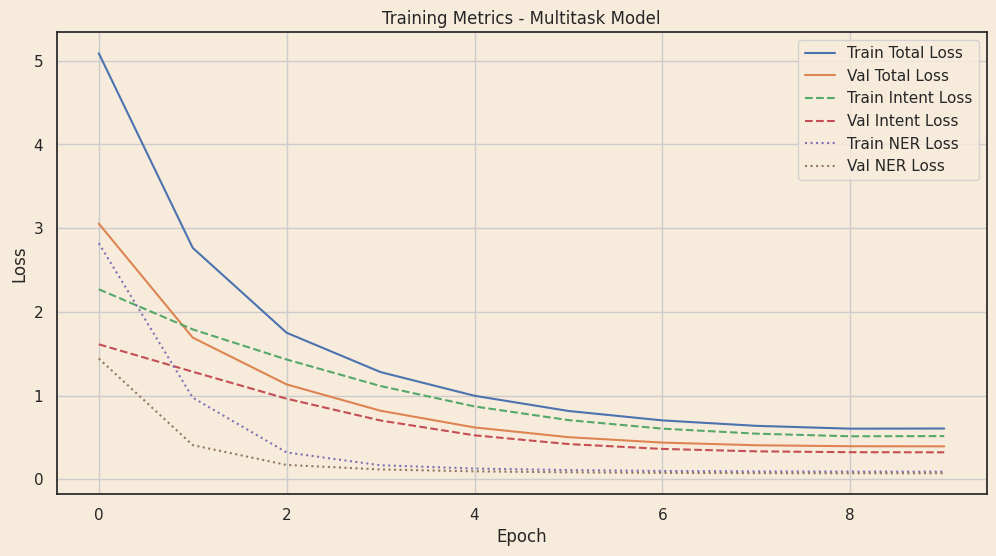

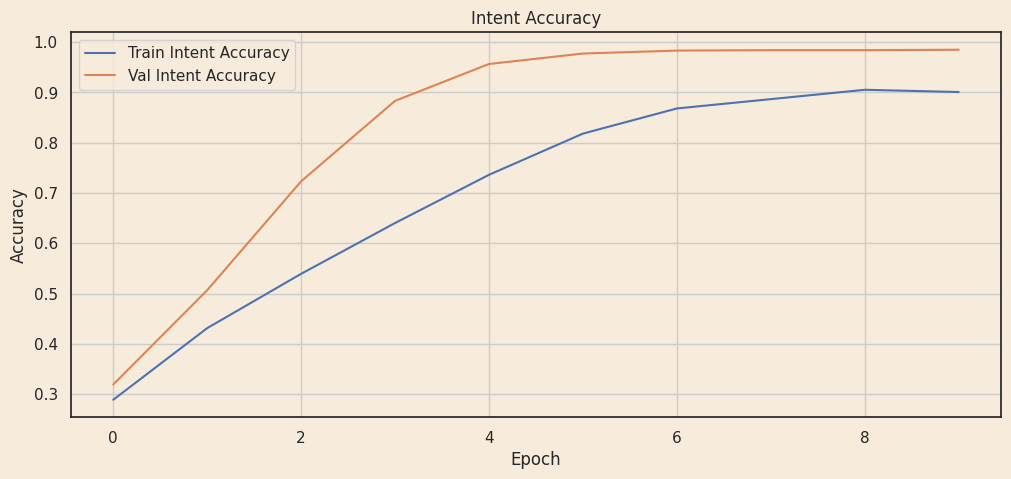

In [ ]:
plot_multitask_history(history)

## Evaluación de resultados

### Métricas utilizadas

**1)  Intent Detection**

Se utilizan **accuracy, precision, recall y F1-score**, calculadas por clase y agregadas como *macro avg* y *weighted avg*.

* **Accuracy**: proporción total de predicciones correctas.
  Es útil como métrica global, pero puede ser engañosa con clases desbalanceadas.

* **Precision**:
  Mide qué tan confiables son las predicciones positivas de una clase. Es clave cuando los falsos positivos son costosos.

  $\text{Precision} = \frac{TP}{TP + FP}$
  
  

* **Recall**:
  
  Indica qué proporción de los casos reales de una clase fueron detectados. Es importante en dominios financieros donde omitir un caso relevante puede ser crítico.

  $
  \text{Recall} = \frac{TP}{TP + FN}
  $

* **F1-score**: media armónica entre precision y recall.
  Es apropiada cuando hay desbalance, porque penaliza modelos que favorecen solo una de las dos métricas.

* **Macro avg**: promedio simple entre clases (evalúa desempeño equilibrado).

* **Weighted avg**: promedio ponderado por soporte (refleja desempeño global real).

Dado que el dataset está claramente desbalanceado el uso de F1 y macro average lo más correcrto.



**2) NER**

Se construye una distribución `true vs pred` token a token ignorando padding.

En NER:

* La unidad de evaluación es el **token**.
* Es fundamental analizar errores tipo:

  * Entidad → O (falsos negativos)
  * O → Entidad (falsos positivos)
  * Confusión B/I

Dado el fuerte desbalance entre etiqueta 'O' y entidades reales (200k vs cientos), analizar la matriz cruzada es adecuado para diagnosticar sesgo hacia la clase dominante.



In [ ]:
df_intent_report, y_true, y_pred = evaluar_intent_df(
    model,
    test_ds,
    id2intent
)


=== Classification Report (Intent) ===
                            precision  recall  f1-score    support
acceso_canales_digitales       1.0000  0.9241    0.9605    79.0000
acreditacion_pago              1.0000  1.0000    1.0000    70.0000
acreditacion_transferencia     0.9804  1.0000    0.9901   100.0000
controversia_compra            1.0000  1.0000    1.0000   281.0000
cuenta_otros                   0.9400  0.9860    0.9625   143.0000
fraude_desconocimiento         1.0000  1.0000    1.0000   144.0000
rechazo_prevencion_fraude      0.9915  1.0000    0.9957   350.0000
token_2fa                      1.0000  0.8182    0.9000    33.0000
accuracy                       0.9883  0.9883    0.9883     0.9883
macro avg                      0.9890  0.9660    0.9761  1200.0000
weighted avg                   0.9887  0.9883    0.9881  1200.0000


Los resultados obtenidos para la tarea de clasificación de intención muestran un desempeño general sólido del modelo.
Se alcanzó una **accuracy de 98%**, con un **F1-score macro de 0.97** y un **F1-score ponderado de 0.99**, lo que indica un buen balance general entre precisión y recall en el conjunto de clases evaluadas.

Se observan muy buenos resultados en clases con mayor soporte y mayor separabilidad semántica, como:

* **controversia_compra** (F1 = 1)
* **fraude_desconocimiento** (F1 = 1)
* **acreditacion_pago** (F1 = 1)

Estas clases presentan alta consistencia en precisión y recall, lo que sugiere que el modelo logra capturar correctamente los patrones semánticos asociados a estos intents.

Las clases con menor soporte muestran un desempeño ligeramente inferior en recall, como:


* **token_2fa** (recall = 0.81)
* **acceso_canales_digitales** (recall = 0.92)


Esto sugiere que el modelo tiende a favorecer clases más frecuentes, comportamiento típico en datasets con cierto grado de desbalance.

En general, los resultados confirman que el modelo presenta una buena capacidad de discriminación entre clases de intención, manteniendo un desempeño robusto incluso en clases menos representadas.

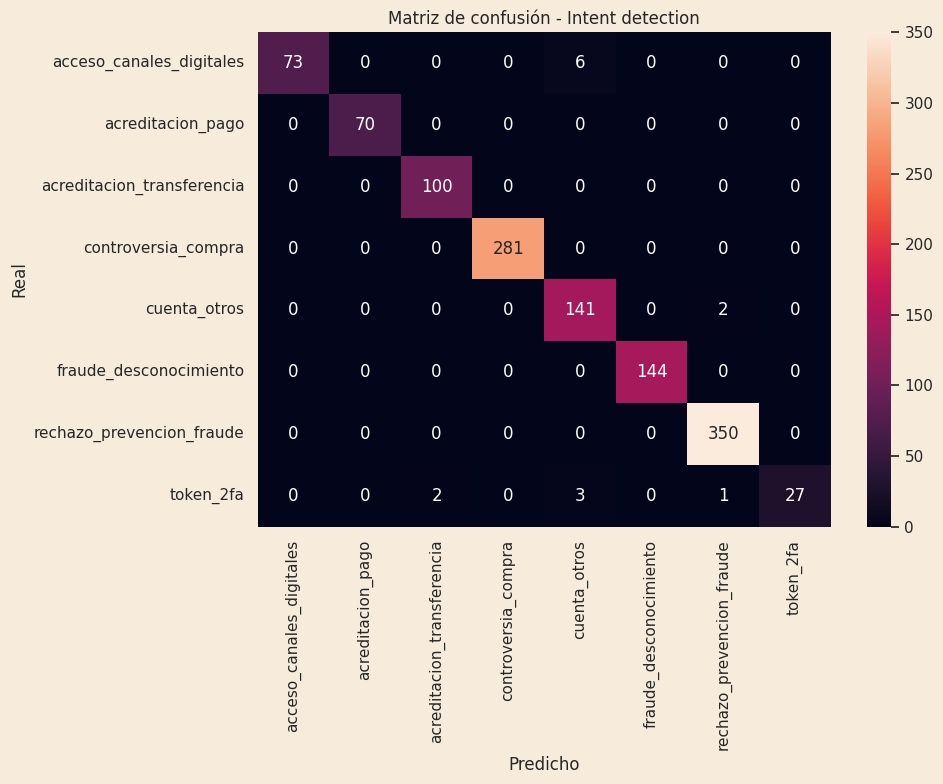

In [ ]:
cm, labels = matriz_confusion_intent(
    y_true,
    y_pred
)

In [ ]:
df_ne_report = evaluar_ner_df(
    model,
    test_ds,
    id2label,
    cfg
)


=== NER Classification Report ===
              precision    recall  f1-score   support

    B-AMOUNT       0.45      0.37      0.40       617
   B-CHANNEL       0.00      0.00      0.00        81
   B-COUNTRY       0.00      0.00      0.00       100
  B-CURRENCY       0.76      0.79      0.77       634
  B-MERCHANT       0.17      0.05      0.08       577
   B-PRODUCT       0.00      0.00      0.00       277
    I-AMOUNT       0.65      0.81      0.72       650
   I-CHANNEL       0.00      0.00      0.00        81
   I-COUNTRY       0.00      0.00      0.00        18
  I-CURRENCY       0.83      0.62      0.71       485
  I-MERCHANT       0.69      0.54      0.61       832
           O       0.99      1.00      0.99    302848

    accuracy                           0.99    307200
   macro avg       0.38      0.35      0.36    307200
weighted avg       0.99      0.99      0.99    307200


=== Confusion Distribution ===
          true        pred   count
0     B-AMOUNT    B-AMOUNT     

El modelo presenta un desempeño global alto en la tarea de NER, con accuracy = 99% y F1 weighted = 0.99. Sin embargo, el F1 macro = 0.32 evidencia un fuerte desbalance en el rendimiento entre clases, principalmente debido a la predominancia de la etiqueta "O".

Se observan buenos resultados en entidades relacionadas con valores monetarios, como I-AMOUNT (F1 = 0.77) y I-CURRENCY (F1 = 0.71). En contraste, entidades con menor soporte como CHANNEL, COUNTRY y PRODUCT presentan bajo desempeño, con F1 cercano a 0.

La matriz de confusión muestra una tendencia del modelo a predecir la clase "O" ante incertidumbre, lo que genera falsos negativos en entidades poco frecuentes y algunos falsos positivos en patrones numéricos.

En general, el modelo es robusto en entidades frecuentes, pero muestra las limitaciones típicas de datasets desbalanceados.

In [ ]:
mostrar_ejemplos_random(
    model,
    test_ds,
    id2intent,
    cfg,
    n=3
)


===== EJEMPLOS RANDOM =====

Texto:

[ CUSTOMER ] Buenas. Soy Sofía. Quiero disputar una compra con mi tarjeta de crédito. [ CUSTOMER ] Me cobraron 2500 UYU
en Airbnb pero el servicio no se prestó o llegó mal. [ AGENT ] Atención [ BANCO ] Para controversias necesitamos fecha,
comprobante y evidencia del reclamo al comercio. [ CUSTOMER ] Sofía : Tengo capturas y comprobante. ¿ Dónde lo adjunto?
[ AGENT ] Atención [ BANCO ] Te ...

Intent real: controversia_compra
Intent pred: controversia_compra

Texto:

[ CUSTOMER ] Hola. Soy Pablo. Quiero disputar una compra con mi tarjeta de débito. [ CUSTOMER ] Me cobraron 2500 EUR en
Steam pero el servicio no se prestó o llegó mal. [ CUSTOMER ] Gracias, quedo atento / a.

Intent real: controversia_compra
Intent pred: controversia_compra

Texto:

[ CUSTOMER ] Buenas tardes. Soy Agustín. Estoy intentando pagar y me rechaza la tarjeta de crédito. [ CUSTOMER ] Me
figura autorización rechazada por 780 USD. [ CUSTOMER ] Perfecto, gracias.

Intent real: 

## Conclusiones y mejoras
El modelo multitarea muestra un desempeño global muy sólido en ambas tareas. En Intent Detection se alcanzaron métricas cercanas al óptimo (accuracy = 98%, F1 macro = 0.97, F1 weighted = 0.99), evidenciando una buena capacidad de clasificación semántica de las intenciones. En NER, el modelo también presenta un alto desempeño global (accuracy = 99%, F1 weighted = 0.99), aunque el F1 macro más bajo (0.32) refleja las dificultades típicas asociadas al desbalance de clases y a la predominancia de la etiqueta "O".

Es importante considerar que el dataset utilizado es completamente sintético, por lo que presenta menor ruido y mayor regularidad que datos reales de producción. Esto puede favorecer el alto desempeño observado, pero limita la evaluación de la capacidad de generalización del modelo en escenarios reales más complejos. En este sentido, se recomienda validar el sistema con datos reales o híbridos para una evaluación más robusta.

Sinembargo, el modelo muestra buenos resultados en línea con lo reportado en *Chen et al., 2019 (BERT for Joint Intent Classification and Slot Filling)* [texto del enlace](https://arxiv.org/pdf/1902.10909). El uso de BERT permite mejor generalización y manejo de vocabulario poco frecuente gracias a sus representaciones contextuales profundas, lo que es especialmente beneficioso incluso en datasets sintéticos con menor ruido y variabilidad. Además, el entrenamiento conjunto de ambas tareas mejora la coherencia semántica y la precisión de las predicciones sin necesidad de arquitecturas más complejas.


**Posibles Mejoras**

- Para Intent

  1. Aumentar peso de clases minoritarias.
  2. Data augmentation sintáctico para clases pequeñas.
  3. Focal Loss en lugar de CrossEntropy.
  4. Analizar embeddings para ver solapamiento semántico.


- Para NER

  1. Aplicar class weights también en NER.
  2. Focal Loss token-level.
  3. Agregar CRF layer sobre NER para mejorar consistencia BIO.
  4. Balancear entidades raras.
  5. Evaluar métricas entity-level (no solo token-level).
  6. Post-procesamiento para evitar secuencias BIO inválidas.
